# Feature engineering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import TargetEncoder, KBinsDiscretizer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from heart_failure.config.config import (
    INTERIM_DATA_DIR, PROCESSED_DATA_DIR, HEART_DISEASE, SEX, AGE, MAX_HR, OLDPEAK, FASTING_BS
)
from heart_failure.config.features import (
    TEST_SIZE,
    RANDOM_STATE,
    TE_CV,
    TE_FEATURES,
    BINARIZED_FEATURES,
    BINARY_CAT_FEATURES,
    Z_SCORED_FEATURES,
    OLDPEAK_TE_FEATURES,
    MAX_HR_TE_FEATURES,
    FASTING_BS_TE_FEATURES,
    RULE_CONDITIONS,
    CONJ_MIN_MASK_COUNT,
    CONJ_MIN_TARGET_RATE,
    SEX_TE_FEATURES
)
from heart_failure.features import (
    GroupZScore,
    TargetEncoderByBins,
    CrossTargetEncoder,
    add_features_ratio,
    ConjRuleAggregator,
    select_by_vif
)
from heart_failure.plots import plot_corr_matrix

2026-06-15 13:06:38.251 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
TARGET_CORR_THRESHOLD = 0.2

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[[SEX, HEART_DISEASE]]
)

### Feature implementing

In [4]:
X_train = add_features_ratio(X_train, AGE, MAX_HR)
X_test = add_features_ratio(X_test, AGE, MAX_HR)

In [5]:
cv = StratifiedKFold(n_splits=TE_CV, shuffle=True, random_state=RANDOM_STATE)

feature_engineering = Pipeline([
    ("rule_aggregator", ConjRuleAggregator(RULE_CONDITIONS, CONJ_MIN_MASK_COUNT, CONJ_MIN_TARGET_RATE)),
    ("group_zscore", GroupZScore([AGE, SEX], Z_SCORED_FEATURES)),
    ("oldpeak_te", TargetEncoderByBins([OLDPEAK], OLDPEAK_TE_FEATURES, n_bins=4, cv=cv)),
    ("te_by_max_hr", TargetEncoderByBins([MAX_HR], MAX_HR_TE_FEATURES, n_bins=4, cv=cv)),
    ("sex_te", TargetEncoderByBins(SEX_TE_FEATURES, [SEX], n_bins=5, cv=cv)),
    ("fasting_bs_te", CrossTargetEncoder(([FASTING_BS], FASTING_BS_TE_FEATURES), cv=cv))
])

In [6]:
X_train = feature_engineering.fit_transform(X_train, y_train)
X_test = feature_engineering.transform(X_test)

In [7]:
preprocessor = ColumnTransformer([
    ("target_encoder", TargetEncoder(cv=cv), TE_FEATURES),
    ("binarizer", KBinsDiscretizer(n_bins=10, encode="ordinal"), BINARIZED_FEATURES),
    ("binary_encoder", OrdinalEncoder(), BINARY_CAT_FEATURES)
], remainder="passthrough")
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('target_encoder', ...), ('binarizer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transforme

In [8]:
X_train = preprocessor.fit_transform(X_train, y_train)
X_test = preprocessor.transform(X_test)

In [10]:
X_train.head()

,target_encoder__RestingECG,target_encoder__ChestPainType,target_encoder__ST_Slope,binarizer__Age,binarizer__Cholesterol,binarizer__MaxHR,binary_encoder__Sex,binary_encoder__FastingBS,binary_encoder__ExerciseAngina,remainder__RestingBP,...,remainder__Oldpeak_ST_Slope_te,remainder__Oldpeak_ExerciseAngina_te,remainder__Oldpeak_ChestPainType_te,remainder__MaxHR_RestingECG_te,remainder__Age_Sex_te,remainder__Cholesterol_Sex_te,remainder__RestingBP_Sex_te,remainder__FastingBS_ST_Slope_te,remainder__FastingBS_ChestPainType_te,remainder__FastingBS_ExerciseAngina_te
382,0.500154,0.784990,0.824971,1.0,5.0,6.0,1.0,0.0,1.0,115.0,...,0.868307,0.913555,0.915732,0.435145,0.369796,0.755600,0.714422,0.771370,0.723544,0.804543
162,0.525940,0.153642,0.190614,2.0,7.0,9.0,1.0,0.0,0.0,160.0,...,0.113732,0.252109,0.059411,0.301169,0.559907,0.689505,0.665611,0.157656,0.121841,0.262830
174,0.525940,0.793146,0.827750,4.0,7.0,4.0,1.0,0.0,1.0,140.0,...,0.858209,0.908868,0.911070,0.625676,0.604076,0.689505,0.662257,0.778606,0.736211,0.816800
154,0.660018,0.122457,0.199339,1.0,8.0,8.0,1.0,0.0,0.0,120.0,...,0.110319,0.243637,0.061119,0.377081,0.403953,0.763536,0.617612,0.158609,0.083884,0.249921
774,0.497331,0.353152,0.833365,0.0,4.0,9.0,1.0,0.0,1.0,120.0,...,0.891474,0.924130,0.424700,0.274971,0.403953,0.789041,0.617612,0.770369,0.222191,0.817780


In [44]:
X_train.isna().sum().sort_values(ascending=False).head()

target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binarizer__Age                   0
binarizer__Cholesterol           0
binarizer__MaxHR                 0
dtype: int64

In [45]:
X_test.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binarizer__Age                   0
binarizer__Cholesterol           0
dtype: int64

### Feature correlation

In [11]:
train = X_train.merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()

In [12]:
plot_corr_matrix(corr_df, width=800, height=800)

Multicollinearity is present. When we calculate gender target encoding (ex.) into bins of some other feature, the probability of class 1 appearing can be repeated across splits by different features. Therefore, they are highly correlated with each other.

In [13]:
low_correlated = corr_df[corr_df[HEART_DISEASE].abs() < TARGET_CORR_THRESHOLD].index.to_list()
low_correlated

['target_encoder__RestingECG',
 'binarizer__Cholesterol',
 'remainder__RestingBP',
 'remainder__Cholesterol_z']

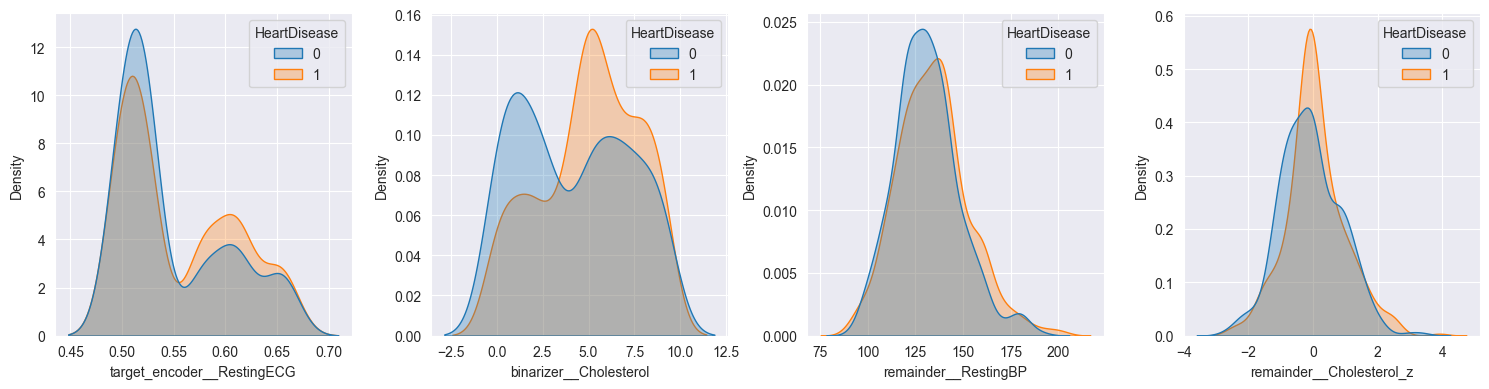

In [14]:
fig, axes = plt.subplots(1, len(low_correlated), figsize=(15, 4))

for ax, f in zip(axes, low_correlated):
    sns.kdeplot(
        train, x=f, hue=HEART_DISEASE, fill=True, common_norm=False, alpha=0.3, ax=ax
    )

plt.tight_layout()
plt.show()

For RestingECG, the correlation was expected to be small (the percentages initially didn't vary much across categories). RestingBP, in its original form, had no effect, so everything is clear here.

The cholesterol z-score was indeed unsuccessful. However, with binning, the class distributions clearly differ, but not so much as to create a significant correlation. This feature can be retained.

In [46]:
low_correlated.remove('binarizer__Cholesterol')
X_train = X_train.drop(columns=low_correlated)
X_test = X_test.drop(columns=low_correlated)

In [40]:
remaining_cols, drop_order = select_by_vif(X_train, y_train)
drop_order

remainder__FastingBS_ChestPainType_te     737.896399
remainder__FastingBS_ST_Slope_te          249.478021
remainder__Oldpeak_ExerciseAngina_te      126.399392
remainder__Age_Sex_te                     111.569421
remainder__FastingBS_ExerciseAngina_te     80.266407
remainder__Age_MaxHR_ratio                 73.133126
remainder__Cholesterol_Sex_te              63.011593
remainder__Oldpeak_ST_Slope_te             51.244843
remainder__RestingBP_Sex_te                49.580714
remainder__Oldpeak_ChestPainType_te        41.281390
remainder__MaxHR_RestingECG_te             19.780242
dtype: float64

In [41]:
remaining_cols

['target_encoder__ChestPainType',
 'target_encoder__ST_Slope',
 'binarizer__Age',
 'binarizer__Cholesterol',
 'binarizer__MaxHR',
 'binary_encoder__Sex',
 'binary_encoder__FastingBS',
 'binary_encoder__ExerciseAngina',
 'remainder__Oldpeak',
 'remainder__conjunctive_rules',
 'remainder__MaxHR_z']

All intergroup features are discarded as duplicate signals. Only the transformed initial features and conjunctive rules remain.

I could try building a model with two sets of features: the first one containing the transformed raw features (remaining columns), and the second one containing combinations of bins and categories. Perhaps in the first case, the model will find the required data depending on where it is, so such pairs of target encodings will be inappropriate.

In [32]:
train = X_train[remaining_cols].merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()
plot_corr_matrix(corr_df, width=600, height=600)

In [49]:
X_train.to_csv(PROCESSED_DATA_DIR / 'train_features.csv')
X_test.to_csv(PROCESSED_DATA_DIR / 'test_features.csv')
y_train.to_csv(PROCESSED_DATA_DIR / 'train_labels.csv')
y_test.to_csv(PROCESSED_DATA_DIR / 'test_labels.csv')
pd.Series(remaining_cols).to_csv(PROCESSED_DATA_DIR / 'remaining_cols.csv')